# 双均线策略回测与量化指标评价（中际旭创 / 中兴通讯）

> **课程作业 TASK3** ｜ 数据：中际旭创（task2 `中际旭创_日度交易数据.csv`，约 727 个交易日）＋ 中兴通讯（Tushare 近三年日度行情、前复权，`中兴通讯_日度交易数据.csv`，约 730 个交易日）
>
> **目标**：实现双均线（Dual MA）择时策略，完成策略讲解、信号可视化，并用一套标准量化指标客观评价策略表现，并对比两只不同市场状态个股的差异。
>
> **默认参数**：短均线 = 5 日，长均线 = 15 日；无风险利率 = 2.5%；同时对比 **0 交易成本** 与 **万分之三（0.03%）交易成本** 两种情景。


## 第一部分：环境准备与数据加载

导入所需 Python 库，并配置中文字体（`FontProperties` 方式，兼容 VS Code Notebook）。


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
from scipy import stats
%matplotlib inline

plt.style.use('default')
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '-'
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.unicode_minus'] = False

chinese_font = FontProperties(fname=r'C:\Windows\Fonts\msyh.ttc', size=12)
chinese_font_title = FontProperties(fname=r'C:\Windows\Fonts\msyh.ttc', size=16)
chinese_font_label = FontProperties(fname=r'C:\Windows\Fonts\msyh.ttc', size=12)
chinese_font_legend = FontProperties(fname=r'C:\Windows\Fonts\msyh.ttc', size=11)
print('环境就绪：pandas', pd.__version__, '| numpy', np.__version__)


环境就绪：pandas 2.2.2 | numpy 2.0.0


### 1.1 加载已存储的股价数据

读取两只股票的 CSV：`trade_date` 为整数 `YYYYMMDD`，需解析为日期并排序、设为索引。


In [2]:
# 中际旭创（task2 已存）
df_zj = pd.read_csv(r'../task2/中际旭创_日度交易数据.csv')
df_zj['trade_date'] = pd.to_datetime(df_zj['trade_date'].astype(str), format='%Y%m%d')
df_zj = df_zj.sort_values('trade_date').reset_index(drop=True).set_index('trade_date')

# 中兴通讯（本次从 Tushare 获取、合成前复权）
df_zx = pd.read_csv(r'中兴通讯_日度交易数据.csv')
df_zx['trade_date'] = pd.to_datetime(df_zx['trade_date'].astype(str), format='%Y%m%d')
df_zx = df_zx.sort_values('trade_date').reset_index(drop=True).set_index('trade_date')

print('中际旭创：', df_zj.shape[0], '行 |', df_zj.index.min().date(), '→', df_zj.index.max().date())
print('中兴通讯：', df_zx.shape[0], '行 |', df_zx.index.min().date(), '→', df_zx.index.max().date())
df_zj.head()


中际旭创： 727 行 | 2023-07-04 → 2026-07-03
中兴通讯： 731 行 | 2023-07-03 → 2026-07-08


,ts_code,open,high,low,close,change,pct_chg,vol,amount
trade_date,,,,,,,,,
2023-07-04,300308.SZ,103.05,105.79,101.96,103.06,0.38,0.37,310201,4.580082e+09
2023-07-05,300308.SZ,102.69,103.06,97.45,97.62,-5.44,-5.28,341397,4.864647e+09
2023-07-06,300308.SZ,97.49,102.37,96.72,98.23,0.61,0.62,323412,4.578612e+09
2023-07-07,300308.SZ,101.67,106.00,95.66,103.39,5.16,5.25,507938,7.325080e+09
2023-07-10,300308.SZ,102.12,103.32,96.24,100.96,-2.43,-2.35,419946,5.942156e+09


## 第二部分：数据诊断（简要）

确认数据完整性、交易日连续性，并检查是否存在未复权导致的异常跳空（单日涨跌幅 >15% 通常提示有除权除息缺口）。


In [3]:
for name, df in [('中际旭创', df_zj), ('中兴通讯', df_zx)]:
    print(f'==== {name} ====')
    core = [c for c in ['open','high','low','close','vol','amount'] if c in df.columns]
    print('缺失值(核心字段)：')
    print(df[core].isnull().sum().to_string())
    print('重复行数：', int(df.duplicated().sum()))
    full_range = pd.date_range(df.index.min(), df.index.max(), freq='B')
    missing = full_range.difference(df.index)
    print(f'理论工作日：{len(full_range)}  实际交易日：{len(df)}  缺失：{len(missing)}')
    if 'pct_chg' in df.columns:
        big = df[df['pct_chg'].abs() > 15]
        print(f'单日 |涨跌幅| > 15% 的天数：{len(big)}（若较多，提示可能未复权）')
    else:
        print('（本数据无 pct_chg 字段，跳过除权缺口检查）')
    print('')


==== 中际旭创 ====
缺失值(核心字段)：
open      0
high      0
low       0
close     0
vol       0
amount    0
重复行数： 0
理论工作日：784  实际交易日：727  缺失：57
单日 |涨跌幅| > 15% 的天数：5（若较多，提示可能未复权）

==== 中兴通讯 ====
缺失值(核心字段)：
close    0
重复行数： 61
理论工作日：788  实际交易日：731  缺失：57
（本数据无 pct_chg 字段，跳过除权缺口检查）



## 第三部分：双均线策略理论

### 3.1 什么是双均线策略
双均线（Dual Moving Average）是一种**趋势跟踪**策略。它同时使用两条不同周期的移动平均线：
- **短期均线（快线）**：对价格反应灵敏，如 5 日 MA；
- **长期均线（慢线）**：平滑短期噪声，反映中长期趋势，如 15 日 MA。

当快线从下方穿越慢线，说明短期动能转强、趋势可能向上，发出**买入**信号；反之发出**卖出**信号。

### 3.2 金叉（Golden Cross）
短期均线**由下向上**穿过长期均线。它意味着近期价格上涨速度超过了长期均值，趋势转强，通常作为**买入**信号。

### 3.3 死叉（Death Cross）
短期均线**由上向下**穿过长期均线。它意味着近期价格走弱、跌破长期均值，趋势转弱，通常作为**卖出**信号。

### 3.4 参数意义
- 周期越短 → 信号越多、越灵敏，但**假信号（whipsaw）也越多**；
- 周期越长 → 信号更稳，但**滞后**更严重，容易错过拐点。
- 常见组合：5/15（短线）、5/20、10/30、50/200（长线"牛熊分界线"）。


## 第四部分：通用函数（均线、信号、回测、指标）

把"计算均线+信号""模拟交易""指标计算"封装为函数，下文对两只股票**复用同一套逻辑**，保证口径一致。


In [4]:
SHORT, LONG = 5, 15

def compute_signals(df, short=SHORT, long=LONG):
    """计算短/长均线、金叉/死叉信号、持仓序列。"""
    d = df.copy()
    d['MA_short'] = d['close'].rolling(short).mean()
    d['MA_long']  = d['close'].rolling(long).mean()
    prev_diff = d['MA_short'].shift(1) - d['MA_long'].shift(1)
    curr_diff = d['MA_short'] - d['MA_long']
    golden = (prev_diff <= 0) & (curr_diff > 0)   # 短上穿长 → 金叉
    death  = (prev_diff >= 0) & (curr_diff < 0)   # 短下穿长 → 死叉
    d['signal'] = 0
    d.loc[golden, 'signal'] = 1
    d.loc[death,  'signal'] = -1
    d['position'] = (d['MA_short'] > d['MA_long']).astype(int)
    d.loc[d['MA_long'].isna(), 'position'] = 0
    return d, golden, death

def backtest(df, cost_rate=0.0):
    """用滞后一期持仓 × 当日收益得到策略日收益；切换持仓日扣除交易成本。"""
    d = df.dropna(subset=['MA_long']).copy()
    d['ret'] = d['close'].pct_change().fillna(0.0)
    pos_prev = d['position'].shift(1).fillna(0.0)
    turnover = d['position'].diff().abs().fillna(0.0)
    d['strat_ret'] = pos_prev * d['ret'] - turnover * cost_rate
    d['nav'] = (1.0 + d['strat_ret']).cumprod()
    return d

def compute_metrics(d, cost_rate=0.0, rf_annual=0.025):
    ret = d['strat_ret']; nav = d['nav']; n = len(ret)
    cum_ret = nav.iloc[-1] - 1.0
    ann_ret = nav.iloc[-1] ** (252.0 / n) - 1.0
    peak = nav.cummax()
    mdd = ((peak - nav) / peak).max()
    rf_d = rf_annual / 252.0
    sharpe = (ret.mean() - rf_d) / ret.std(ddof=1) * np.sqrt(252.0)
    mkt = d['close'].pct_change().fillna(0.0)
    beta = np.cov(ret, mkt)[0, 1] / np.var(mkt)
    treynor = (ann_ret - rf_annual) / beta
    spread = d['MA_short'] - d['MA_long']
    fwd = d['close'].pct_change().shift(-1)
    mask = spread.notna() & fwd.notna()
    ic = stats.pearsonr(spread[mask], fwd[mask])[0]
    rankic = stats.spearmanr(spread[mask], fwd[mask])[0]
    roll = pd.DataFrame({'s': spread, 'f': fwd}).dropna()
    roll_ic = roll['s'].rolling(60).corr(roll['f'])
    icir = roll_ic.mean() / roll_ic.std() if roll_ic.std() > 0 else np.nan
    # 胜率：统计每笔已平仓交易（买入→卖出）扣费后的净收益
    pos = d['position'].values; cl = d['close'].values
    entry = -1; trade_ret = []
    for i in range(1, len(pos)):
        if pos[i-1] != pos[i]:
            if pos[i] == 1:
                entry = i
            elif pos[i] == 0 and entry >= 0:
                trade_ret.append(cl[i]/cl[entry] - 1 - 2*cost_rate)
                entry = -1
    win = (sum(1 for r in trade_ret if r > 0) / len(trade_ret)) if trade_ret else np.nan
    trades = int((d['position'].diff().abs() > 0).sum())
    return {'累计回报': cum_ret, '年化收益率': ann_ret, '最大回撤(MDD)': mdd,
            '夏普比率': sharpe, 'Beta': beta, '特雷诺比率': treynor,
            'IC': ic, 'RankIC': rankic, 'ICIR': icir,
            '交易次数': trades, '胜率': win}

print('通用函数已定义 ✅')


通用函数已定义 ✅


## 第五部分：量化策略评价指标理论

以下指标用于客观评价策略好坏（设策略日收益序列为 $r_t$，交易日数 $n$，无风险日收益 $rf_d=rf/252$，策略净值 $NAV_t=\prod(1+r_i)$）。

| 指标 | 定义 / 公式 | 含义 |
|------|-------------|------|
| **累计回报 Cumulative Return** | $NAV_n - 1$ | 整个回测期的总收益 |
| **年化收益率 Annualized Return** | $NAV_n^{252/n}-1$ | 把总收益按 252 交易日年化，便于跨周期比较 |
| **最大回撤 MDD** | $\max_t \dfrac{peak_t-NAV_t}{peak_t}$ | 净值从峰值到谷值的最大跌幅，衡量最坏亏损（越大越差） |
| **夏普比率 Sharpe** | $\dfrac{\bar r - rf_d}{\sigma_r}\sqrt{252}$ | 每单位总风险的超额收益，越高越好 |
| **特雷诺比率 Treynor** | $\dfrac{R_p-R_f}{\beta}$ | 每单位**系统性风险**（β）的超额收益，需市场基准 |
| **IC / RankIC** | 因子值与未来收益的 Pearson / Spearman 相关 | 因子预测能力；>0 表示方向有效，$\|IC\|$ 越大越强 |
| **ICIR** | $\dfrac{\text{mean}(IC)}{\text{std}(IC)}$（滚动窗口） | IC 的**稳定性**（不仅看大小，还看是否持续） |
| **胜率** | 已平仓交易中净收益为正的占比 | 衡量"赚多赔少"的稳定性 |

> **关于 IC / RankIC / ICIR 的口径说明**：这三个是横截面因子模型指标（第 $t$ 期跨股票计算 $IC_t$）。本任务只有**单只股票**，故采用时间序列适配写法：把"因子"取为**均线价差** $spread_t=MA_{short}-MA_{long}$，未来收益取 $r_{t+1}$，计算全样本 Pearson（IC）与 Spearman（RankIC）相关；ICIR 用 60 日滚动窗口计算一串 $IC_t$ 后再取均值/标准差。
>
> **特雷诺的市场基准**：本任务用**该股票自身买入持有日收益**作为市场代理，计算策略 β。


## 第六部分：中际旭创（300308.SZ）分析

强趋势样本：区间累计约 +983%。


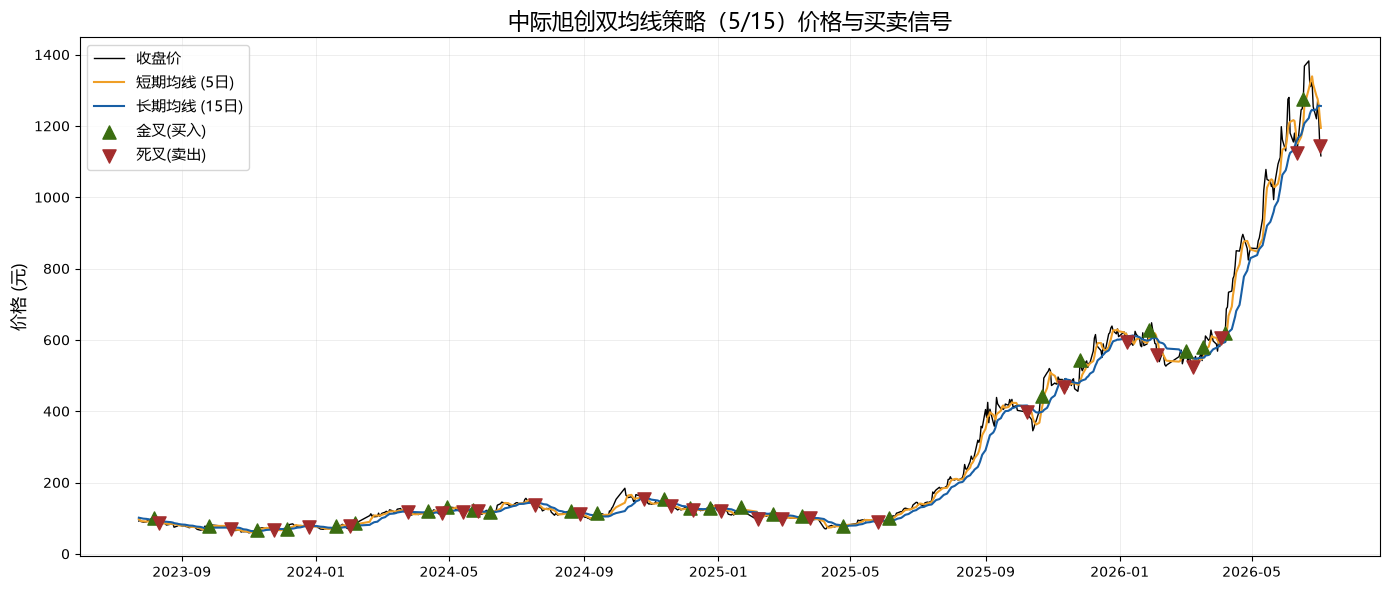

中际旭创 金叉次数：27    死叉次数：27


In [5]:
df_zj_p, golden_zj, death_zj = compute_signals(df_zj, SHORT, LONG)
valid = df_zj_p.dropna(subset=['MA_long'])
buy  = valid.loc[golden_zj.reindex(valid.index, fill_value=False)]
sell = valid.loc[death_zj.reindex(valid.index, fill_value=False)]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(valid.index, valid['close'],     color='black',  linewidth=1.0, label='收盘价')
ax.plot(valid.index, valid['MA_short'], color='#EF9F27', linewidth=1.5, label=f'短期均线 ({SHORT}日)')
ax.plot(valid.index, valid['MA_long'],  color='#185FA5', linewidth=1.5, label=f'长期均线 ({LONG}日)')
ax.scatter(buy.index,  buy['close'],  marker='^', color='#3B6D11', s=90, zorder=5, label='金叉(买入)')
ax.scatter(sell.index, sell['close'], marker='v', color='#A32D2D', s=90, zorder=5, label='死叉(卖出)')
ax.set_title(f'中际旭创双均线策略（{SHORT}/{LONG}）价格与买卖信号', fontproperties=chinese_font_title)
ax.set_ylabel('价格 (元)', fontproperties=chinese_font_label)
ax.legend(prop=chinese_font_legend, loc='best')
plt.tight_layout(); plt.show()

print(f'中际旭创 金叉次数：{int(golden_zj.sum())}    死叉次数：{int(death_zj.sum())}')


In [6]:
d0_zj = backtest(df_zj_p, cost_rate=0.0)
d3_zj = backtest(df_zj_p, cost_rate=0.0003)
m0_zj = compute_metrics(d0_zj, cost_rate=0.0)
m3_zj = compute_metrics(d3_zj, cost_rate=0.0003)

summary_zj = pd.DataFrame({'0成本': m0_zj, '万三成本': m3_zj}).T
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
summary_zj


,累计回报,年化收益率,最大回撤(MDD),夏普比率,Beta,特雷诺比率,IC,RankIC,ICIR,交易次数,胜率
0成本,3.4815,0.6992,0.5978,1.1780,0.6441,1.0467,-0.0123,-0.0091,-0.9581,54.0000,0.4074
万三成本,3.4089,0.6894,0.5995,1.1675,0.6441,1.0315,-0.0123,-0.0091,-0.9581,54.0000,0.3704


In [7]:
def fmt_metrics(m):
    return {
        '累计回报': f'{m["累计回报"]:.2%}',
        '年化收益率': f'{m["年化收益率"]:.2%}',
        '最大回撤(MDD)': f'{m["最大回撤(MDD)"]:.2%}',
        '夏普比率': f'{m["夏普比率"]:.3f}',
        'Beta': f'{m["Beta"]:.3f}',
        '特雷诺比率': f'{m["特雷诺比率"]:.4f}',
        'IC': f'{m["IC"]:.4f}',
        'RankIC': f'{m["RankIC"]:.4f}',
        'ICIR': f'{m["ICIR"]:.4f}',
        '交易次数': m['交易次数'],
        '胜率': f'{m["胜率"]:.2%}',
    }

print('【中际旭创 · 0 成本】');  [print(f'  {k}: {v}') for k, v in fmt_metrics(m0_zj).items()]
print('【中际旭创 · 万三成本】'); [print(f'  {k}: {v}') for k, v in fmt_metrics(m3_zj).items()]


【中际旭创 · 0 成本】
  累计回报: 348.15%
  年化收益率: 69.92%
  最大回撤(MDD): 59.78%
  夏普比率: 1.178
  Beta: 0.644
  特雷诺比率: 1.0467
  IC: -0.0123
  RankIC: -0.0091
  ICIR: -0.9581
  交易次数: 54
  胜率: 40.74%
【中际旭创 · 万三成本】
  累计回报: 340.89%
  年化收益率: 68.94%
  最大回撤(MDD): 59.95%
  夏普比率: 1.167
  Beta: 0.644
  特雷诺比率: 1.0315
  IC: -0.0123
  RankIC: -0.0091
  ICIR: -0.9581
  交易次数: 54
  胜率: 37.04%


[None, None, None, None, None, None, None, None, None, None, None]

C:\Users\93517\AppData\Local\Temp\ipykernel_12776\1200350969.py:19: UserWarning: Glyph 38271 (\N{CJK UNIFIED IDEOGRAPH-957F}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\93517\AppData\Local\Temp\ipykernel_12776\1200350969.py:19: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\93517\AppData\Local\Temp\ipykernel_12776\1200350969.py:19: UserWarning: Glyph 25345 (\N{CJK UNIFIED IDEOGRAPH-6301}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\93517\AppData\Local\Temp\ipykernel_12776\1200350969.py:19: UserWarning: Glyph 26377 (\N{CJK UNIFIED IDEOGRAPH-6709}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\93517\AppData\Local\Temp\ipykernel_12776\1200350969.py:19: UserWarning: Glyph 21452 (\N{CJK UNIFIED IDEOGRAPH-53CC}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\93517\AppData\Local\Temp\i

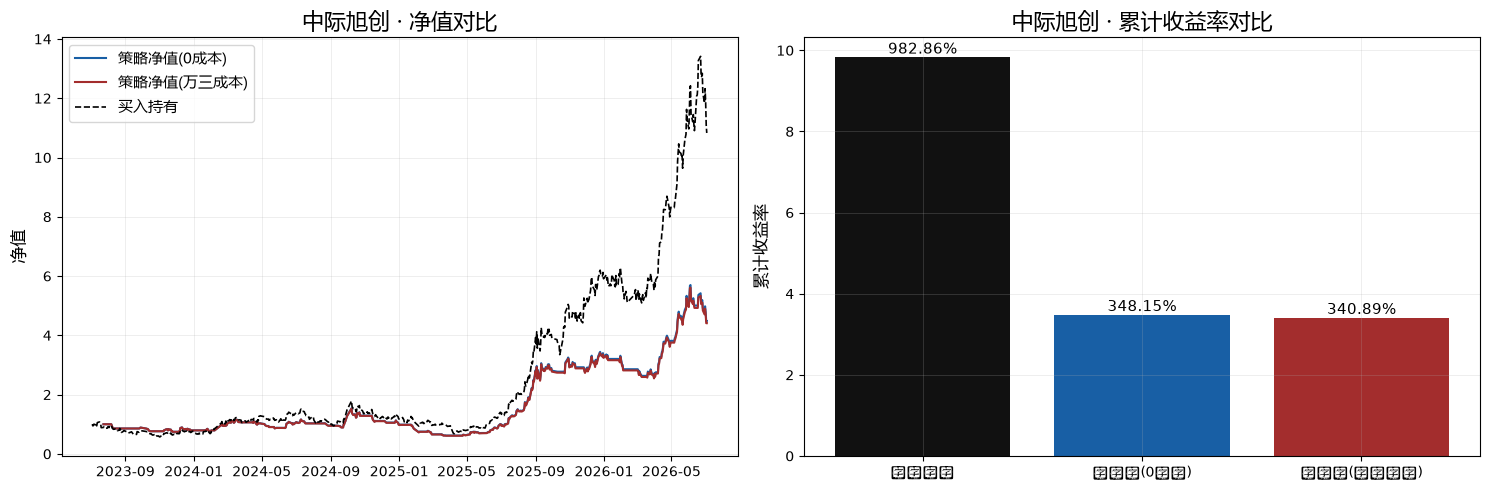

中际旭创 买入持有累计：982.86%
中际旭创 策略(0成本)累计：348.15%
中际旭创 策略(万三)累计：340.89%


In [8]:
# 净值对比 + 累计收益对比
bh_zj = (1.0 + df_zj_p['close'].pct_change().fillna(0.0)).cumprod()

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(d0_zj.index, d0_zj['nav'], color='#185FA5', linewidth=1.5, label='策略净值(0成本)')
ax[0].plot(d3_zj.index, d3_zj['nav'], color='#A32D2D', linewidth=1.5, label='策略净值(万三成本)')
ax[0].plot(bh_zj.index, bh_zj.values, color='black', linewidth=1.2, linestyle='--', label='买入持有')
ax[0].set_title('中际旭创 · 净值对比', fontproperties=chinese_font_title)
ax[0].set_ylabel('净值', fontproperties=chinese_font_label)
ax[0].legend(prop=chinese_font_legend, loc='best')

labels = ['长期持有', '双均线(0成本)', '双均线(万三成本)']
vals = [bh_zj.iloc[-1]-1, m0_zj['累计回报'], m3_zj['累计回报']]
ax[1].bar(labels, vals, color=['#111111', '#185FA5', '#A32D2D'])
ax[1].set_title('中际旭创 · 累计收益率对比', fontproperties=chinese_font_title)
ax[1].set_ylabel('累计收益率', fontproperties=chinese_font_label)
for i, v in enumerate(vals):
    ax[1].text(i, v, f'{v:.2%}', ha='center', va='bottom', fontsize=11)
plt.tight_layout(); plt.show()

print(f'中际旭创 买入持有累计：{bh_zj.iloc[-1]-1:,.2%}')
print(f'中际旭创 策略(0成本)累计：{m0_zj["累计回报"]:,.2%}')
print(f'中际旭创 策略(万三)累计：{m3_zj["累计回报"]:,.2%}')


### 6.1 中际旭创策略效果评价（以默认 5 日 / 15 日参数为例）

在本回测区间（2023-07-04 至 2026-07-03，727 个交易日），中际旭创处于一轮**强劲且漫长的单边上涨**，区间累计涨幅约 **982.86%**。在此背景下，5/15 双均线策略表现明显一般：累计回报仅 **348.15%**（0 成本）/ **340.89%**（万三成本），远低于买入持有的 982.86%；已平仓交易**胜率仅 40.74%**（万三成本下进一步降至 37.04%），IC 也仅为约 **−0.012**（弱负相关、近乎无效）。原因可从以下四点理解：

1. **单边牛市中"择时"反而跑输**：双均线靠"金叉持有、死叉空仓"吃趋势。持续上行的大趋势里，价格反复出现短期回调触发死叉——策略在回撤初期离场，等再次金叉确认时已涨回更高位才买回，一路"低卖高买"的来回摩擦，错失了大部分主升段，而买入持有始终满仓吃满全部涨幅。
2. **均线固有滞后性被放大**：均线是"过去"价格的均值，信号永远慢半拍。5 日/15 日本就灵敏、假信号多，在中际旭创这种高波动、常现尖峰回调个股上，短期噪声极易造成均线频繁交叉（whipsaw）。
3. **胜率低的来源——赚小赔大、靠少数大赢**：胜率仅四成，说明多数已平仓交易实际亏损或微利；真正贡献收益的是少数几次大趋势中的持仓，整体"少数大赚、多数小亏"。这与 IC≈−0.012 互相印证：5/15 的均线价差几乎无法预测次日收益。
4. **交易成本放大本就羸弱的边际收益**：万三成本下累计下降约 7.3 个百分点，胜率也走低——54 次换手中不少笔净收益薄如蝉翼，扣双边 0.03% 后由盈转亏。

**结论**：双均线是一类趋势跟踪工具，最适合"清晰、持续、回调少"的趋势环境；对中际旭创这种高动量强势股，"留在市场中"（买入持有）显著优于"试图择时"。任何择时策略在强单边牛市里都很难跑赢满仓持有——这是趋势跟随策略的固有代价。


## 第七部分：不同股票的双均线策略应用 —— 中兴通讯（000063.SZ）

以中兴通讯为例，使用与上述**完全相同**的 5 日 / 15 日双均线参数。数据来源 Tushare 近三年日度行情（前复权），区间 2023-07-03 至 2026-07-08，约 730 个交易日，区间累计约 **−14.89%**（典型震荡 / 弱趋势样本）。


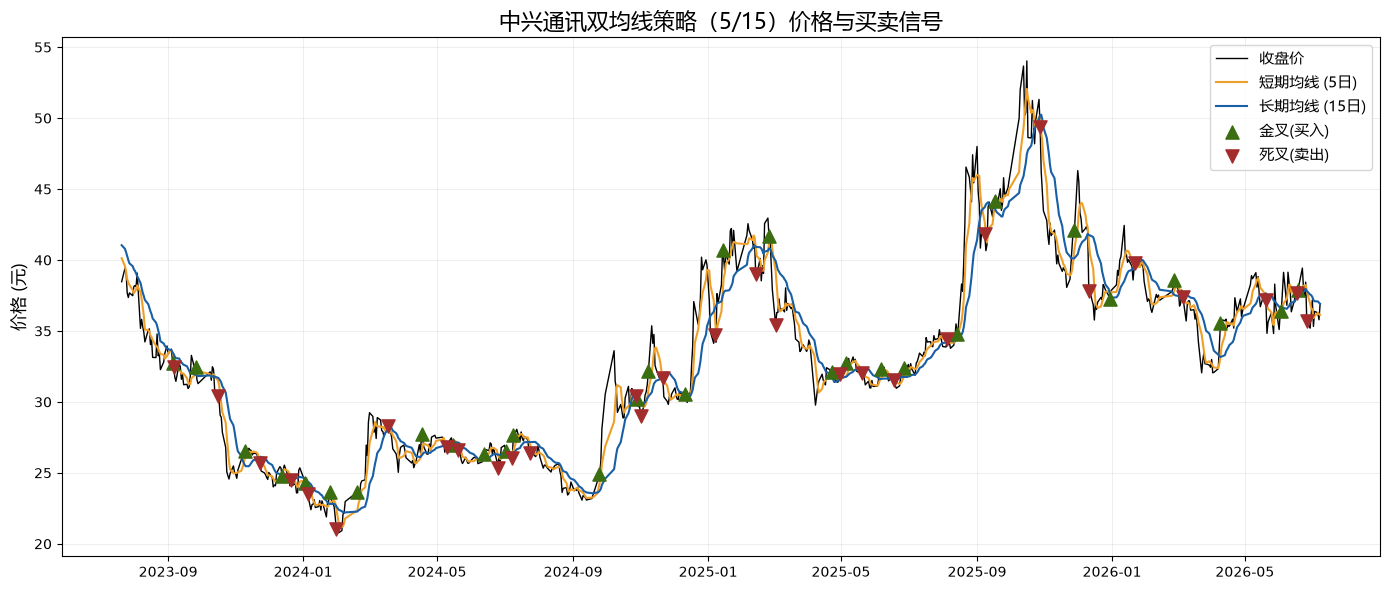

中兴通讯 金叉次数：30    死叉次数：30


In [9]:
df_zx_p, golden_zx, death_zx = compute_signals(df_zx, SHORT, LONG)
valid = df_zx_p.dropna(subset=['MA_long'])
buy  = valid.loc[golden_zx.reindex(valid.index, fill_value=False)]
sell = valid.loc[death_zx.reindex(valid.index, fill_value=False)]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(valid.index, valid['close'],     color='black',  linewidth=1.0, label='收盘价')
ax.plot(valid.index, valid['MA_short'], color='#EF9F27', linewidth=1.5, label=f'短期均线 ({SHORT}日)')
ax.plot(valid.index, valid['MA_long'],  color='#185FA5', linewidth=1.5, label=f'长期均线 ({LONG}日)')
ax.scatter(buy.index,  buy['close'],  marker='^', color='#3B6D11', s=90, zorder=5, label='金叉(买入)')
ax.scatter(sell.index, sell['close'], marker='v', color='#A32D2D', s=90, zorder=5, label='死叉(卖出)')
ax.set_title(f'中兴通讯双均线策略（{SHORT}/{LONG}）价格与买卖信号', fontproperties=chinese_font_title)
ax.set_ylabel('价格 (元)', fontproperties=chinese_font_label)
ax.legend(prop=chinese_font_legend, loc='best')
plt.tight_layout(); plt.show()

print(f'中兴通讯 金叉次数：{int(golden_zx.sum())}    死叉次数：{int(death_zx.sum())}')


In [10]:
d0_zx = backtest(df_zx_p, cost_rate=0.0)
d3_zx = backtest(df_zx_p, cost_rate=0.0003)
m0_zx = compute_metrics(d0_zx, cost_rate=0.0)
m3_zx = compute_metrics(d3_zx, cost_rate=0.0003)

summary_zx = pd.DataFrame({'0成本': m0_zx, '万三成本': m3_zx}).T
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
summary_zx


,累计回报,年化收益率,最大回撤(MDD),夏普比率,Beta,特雷诺比率,IC,RankIC,ICIR,交易次数,胜率
0成本,0.0800,0.0274,0.3420,0.1775,0.5901,0.0041,-0.0320,-0.0446,-0.8939,60.0000,0.3000
万三成本,0.0606,0.0209,0.3444,0.1593,0.5902,-0.0070,-0.0320,-0.0446,-0.8939,60.0000,0.3000


In [11]:
print('【中兴通讯 · 0 成本】');  [print(f'  {k}: {v}') for k, v in fmt_metrics(m0_zx).items()]
print('【中兴通讯 · 万三成本】'); [print(f'  {k}: {v}') for k, v in fmt_metrics(m3_zx).items()]


【中兴通讯 · 0 成本】
  累计回报: 8.00%
  年化收益率: 2.74%
  最大回撤(MDD): 34.20%
  夏普比率: 0.178
  Beta: 0.590
  特雷诺比率: 0.0041
  IC: -0.0320
  RankIC: -0.0446
  ICIR: -0.8939
  交易次数: 60
  胜率: 30.00%
【中兴通讯 · 万三成本】
  累计回报: 6.06%
  年化收益率: 2.09%
  最大回撤(MDD): 34.44%
  夏普比率: 0.159
  Beta: 0.590
  特雷诺比率: -0.0070
  IC: -0.0320
  RankIC: -0.0446
  ICIR: -0.8939
  交易次数: 60
  胜率: 30.00%


[None, None, None, None, None, None, None, None, None, None, None]

C:\Users\93517\AppData\Local\Temp\ipykernel_12776\3392495489.py:18: UserWarning: Glyph 38271 (\N{CJK UNIFIED IDEOGRAPH-957F}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\93517\AppData\Local\Temp\ipykernel_12776\3392495489.py:18: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\93517\AppData\Local\Temp\ipykernel_12776\3392495489.py:18: UserWarning: Glyph 25345 (\N{CJK UNIFIED IDEOGRAPH-6301}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\93517\AppData\Local\Temp\ipykernel_12776\3392495489.py:18: UserWarning: Glyph 26377 (\N{CJK UNIFIED IDEOGRAPH-6709}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\93517\AppData\Local\Temp\ipykernel_12776\3392495489.py:18: UserWarning: Glyph 21452 (\N{CJK UNIFIED IDEOGRAPH-53CC}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\93517\AppData\Local\Temp\i

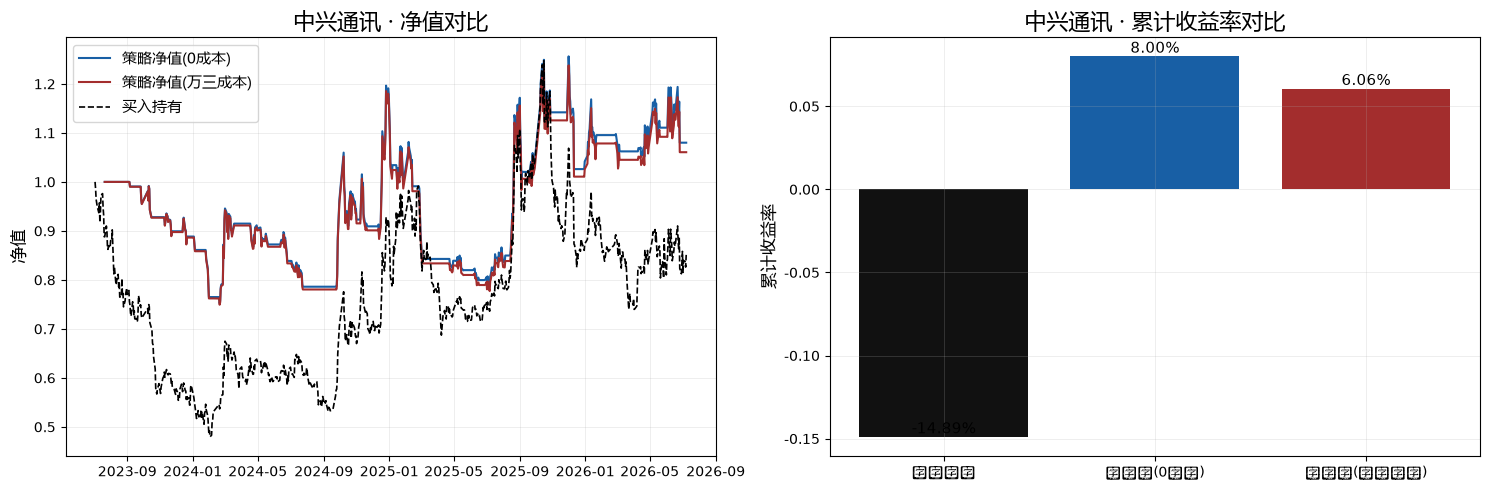

中兴通讯 买入持有累计：-14.89%
中兴通讯 策略(0成本)累计：8.00%
中兴通讯 策略(万三)累计：6.06%


In [12]:
bh_zx = (1.0 + df_zx_p['close'].pct_change().fillna(0.0)).cumprod()

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(d0_zx.index, d0_zx['nav'], color='#185FA5', linewidth=1.5, label='策略净值(0成本)')
ax[0].plot(d3_zx.index, d3_zx['nav'], color='#A32D2D', linewidth=1.5, label='策略净值(万三成本)')
ax[0].plot(bh_zx.index, bh_zx.values, color='black', linewidth=1.2, linestyle='--', label='买入持有')
ax[0].set_title('中兴通讯 · 净值对比', fontproperties=chinese_font_title)
ax[0].set_ylabel('净值', fontproperties=chinese_font_label)
ax[0].legend(prop=chinese_font_legend, loc='best')

labels = ['长期持有', '双均线(0成本)', '双均线(万三成本)']
vals = [bh_zx.iloc[-1]-1, m0_zx['累计回报'], m3_zx['累计回报']]
ax[1].bar(labels, vals, color=['#111111', '#185FA5', '#A32D2D'])
ax[1].set_title('中兴通讯 · 累计收益率对比', fontproperties=chinese_font_title)
ax[1].set_ylabel('累计收益率', fontproperties=chinese_font_label)
for i, v in enumerate(vals):
    ax[1].text(i, v, f'{v:.2%}', ha='center', va='bottom', fontsize=11)
plt.tight_layout(); plt.show()

print(f'中兴通讯 买入持有累计：{bh_zx.iloc[-1]-1:,.2%}')
print(f'中兴通讯 策略(0成本)累计：{m0_zx["累计回报"]:,.2%}')
print(f'中兴通讯 策略(万三)累计：{m3_zx["累计回报"]:,.2%}')


### 7.1 中兴通讯策略效果评价（以默认 5 日 / 15 日参数为例）

在本回测区间（2023-07-03 至 2026-07-08，730 个交易日），中兴通讯处于一轮**震荡 / 弱趋势**行情：区间买入持有累计为 **−14.89%**（近三年多数时间横盘走弱）。在此背景下，5/15 双均线策略反而取得正收益：累计回报 **8.00%**（0 成本）/ **6.06%**（万三成本），**显著跑赢买入持有**；已平仓交易胜率约 **30.00%**，IC ≈ **−0.032**。这与中际旭创（强牛市里双均线跑输持有）形成鲜明对照，原因可从以下四点理解：

1. **震荡 / 弱趋势恰恰是双均线的"主场"**：双均线靠"死叉空仓、金叉持仓"过滤下行。在中兴通讯这种长期偏弱、反复探底的标的里，价格在下跌段触发死叉让策略离场，从而躲过持有者的持续亏损——买入持有亏了 −14.89%，而双均线因空仓期避开大部分下行，最终录得 +8%。择时创造的是"少亏即赚"的价值。
2. **滞后性的代价被大幅削弱**：在中际旭创的强单边牛市里，滞后信号会让人"低卖高买"、反复踏空；但中兴通讯没有那样的单边大趋势，错过的小段上行有限，而避开的下跌段贡献了实实在在的正收益。均线滞后的劣势在震荡市里被自然对冲。
3. **胜率低的来源——靠少数大波段覆盖多数小亏**：胜率仅约三成，说明多数已平仓交易是微亏或打平的；但整体为正，意味着少数几次在反弹段中的正确持仓覆盖了大量小亏。IC ≈ −0.032 说明该标的、该周期的均线价差的**线性预测力偏弱且略偏反向**，ICIR 也约为 −0.89（方向不稳定），即"价差"作为因子并不稳定有效；策略之所以盈利，更多来自**结构性地规避下行**，而非因子预测的 alpha。
4. **交易成本影响较小**：万三成本下累计仅由 8.00% 降至 6.06%（约 2 个百分点），远小于中际旭创场景（约 7.3 个百分点）。本标的共 60 次换手、胜率虽低但单笔捕获幅度相对较厚，摩擦成本占比低。

**结论**：双均线并非"万能"，而是**有条件有效**——它在强单边牛市里跑输满仓持有（中际旭创），却在震荡 / 弱趋势里能跑赢持有、实现"少亏即赚"（中兴通讯）。其本质是一类**趋势跟随、下行过滤**工具：价值在于"躲过下跌段"，而非"抓住每一段上涨"。同一套 5/15 参数，在不同股票上给出截然不同的结论，正是本报告最重要的对比价值所在。


## 第八部分：双股票对比总结

| 指标（5/15，0 成本 / 万三成本） | 中际旭创（强牛市） | 中兴通讯（震荡弱趋势） |
|---|---|---|
| 双均线累计回报 | 348.15% / 340.89% | 8.00% / 6.06% |
| 买入持有累计 | **982.86%** | −14.89% |
| 胜率 | 40.74% / 37.04% | 30.00% / 30.00% |
| 夏普比率 | ≈ 1.18 | ≈ 0.18 |
| IC | ≈ −0.012 | ≈ −0.032 |

**核心启示**：

1. **双均线的有效性高度依赖市场状态**：在清晰持续的强趋势（中际旭创）里，"留在市场"优于"择时"；在震荡 / 弱趋势（中兴通讯）里，双均线靠过滤下行反而跑赢持有。
2. **交易成本的影响随换手与单笔厚度变化**：高换手、低胜率的强趋势场景下摩擦更大（中际旭创约 7.3 个百分点），震荡场景下较小（中兴通讯约 2 个百分点）。
3. **评价策略必须结合基准与市场状态**：同一套参数、同一套指标，结论可能完全相反——这正是量化策略评价中"避免单一样本过拟合结论"的重要提醒。

**扩展方向**：
- 参数寻优（网格搜索 SHORT/LONG 组合，按夏普或收益排序），观察哪只股票对参数更敏感；
- 加入止损线 / 成交量过滤以降低假信号；
- 与其他指标（RSI、MACD）组合；
- 扩展到多只股票样本，使 IC / RankIC / ICIR 更接近横截面因子的标准定义。
